**1 Initialize the Python Environment**

In [12]:
import os
import cv2
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Verify GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Check the mounted data directories
DATA_DIR = '/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test'
print("\nContents of the train directory:")
print(os.listdir(DATA_DIR)[:5]) # Should output folders like 'images' and 'labels'

Using device: cuda
GPU Name: Tesla T4

Contents of the train directory:
['test', 'train']


**2 The Bounding Box Extraction Script**

In [13]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.geometry import mapping

# 1. Define your base paths
BASE_DIR = '/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train'
IMG_DIR = os.path.join(BASE_DIR, 'images')
LBL_DIR = os.path.join(BASE_DIR, 'labels')

def get_building_crops_and_labels(base_filename):
    """
    Extracts building crops and damage labels for a given pre/post pair.
    """
    # File paths
    pre_img_path = os.path.join(IMG_DIR, f"{base_filename}_pre_disaster.png")
    post_img_path = os.path.join(IMG_DIR, f"{base_filename}_post_disaster.png")
    post_json_path = os.path.join(LBL_DIR, f"{base_filename}_post_disaster.json")
    
    # Load images (convert BGR to RGB for matplotlib/model compatibility)
    pre_img = cv2.cvtColor(cv2.imread(pre_img_path), cv2.COLOR_BGR2RGB)
    post_img = cv2.cvtColor(cv2.imread(post_img_path), cv2.COLOR_BGR2RGB)
    
    # Load Post-disaster JSON to get polygons and damage labels
    with open(post_json_path, 'r') as f:
        post_data = json.load(f)
        
    buildings = post_data['features']['xy']
    
    crops = []
    
    for building in buildings:
        # Extract properties
        properties = building['properties']
        
        # Skip if it's not a building
        if 'feature_type' in properties and properties['feature_type'] != 'building':
            continue
            
        # Get damage label (default to un-classified if missing)
        damage_type = properties.get('subtype', 'un-classified')
        
        # Get Polygon and calculate bounding box
        polygon_wkt = building['wkt']
        poly = wkt.loads(polygon_wkt)
        minx, miny, maxx, maxy = poly.bounds
        
        # Expand bounding box slightly for context (optional padding)
        pad = 5
        miny, maxy = max(0, int(miny)-pad), min(pre_img.shape[0], int(maxy)+pad)
        minx, maxx = max(0, int(minx)-pad), min(pre_img.shape[1], int(maxx)+pad)
        
        # Crop the images
        pre_crop = pre_img[miny:maxy, minx:maxx]
        post_crop = post_img[miny:maxy, minx:maxx]
        
        # We resize them to 224x224 as required by ResNet50/EfficientNet
        if pre_crop.size > 0 and post_crop.size > 0:
            pre_crop = cv2.resize(pre_crop, (224, 224))
            post_crop = cv2.resize(post_crop, (224, 224))
            crops.append((pre_crop, post_crop, damage_type))
            
    return crops

print("Function ready!")

Function ready!


**3 Visualize a Pre- and Post-Disaster Pair**

Extracting buildings from guatemala-volcano_00000000...
Total buildings found: 10


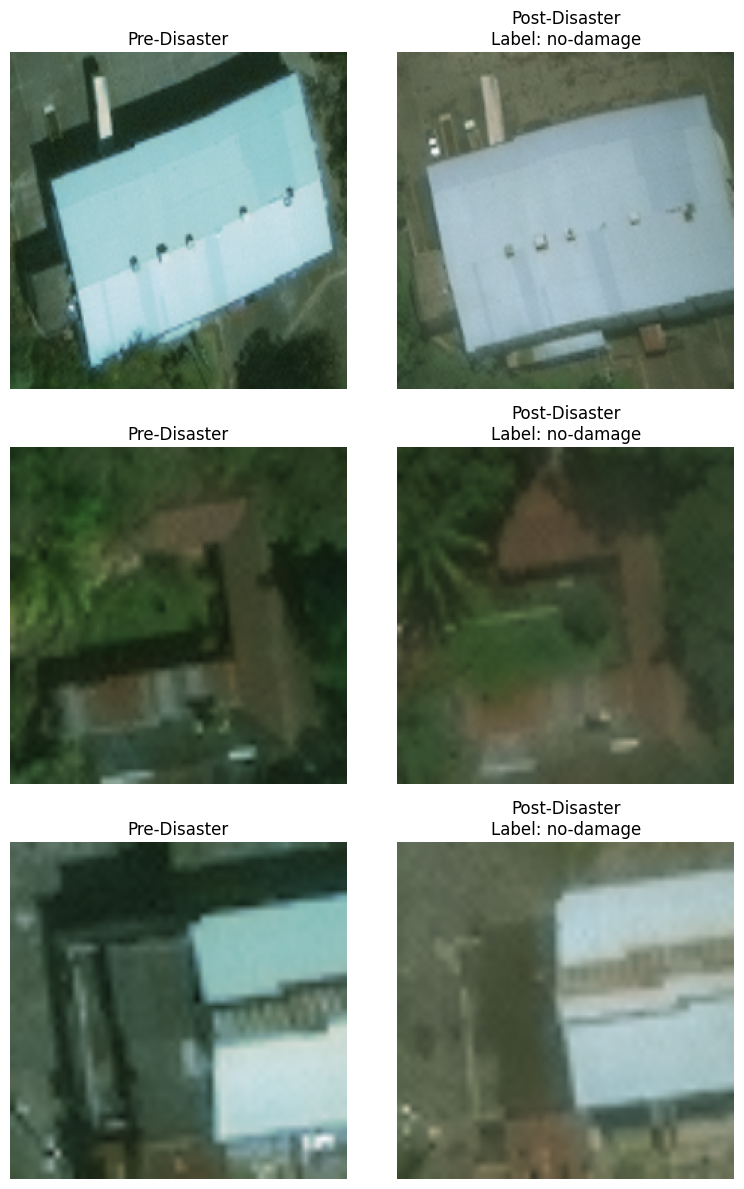

In [14]:
# Test on your specific example file
base_file = "guatemala-volcano_00000000"

print(f"Extracting buildings from {base_file}...")
building_crops = get_building_crops_and_labels(base_file)

print(f"Total buildings found: {len(building_crops)}")

# Visualize the first 3 buildings
num_to_show = min(3, len(building_crops))

fig, axes = plt.subplots(num_to_show, 2, figsize=(8, 4 * num_to_show))

for i in range(num_to_show):
    pre_c, post_c, label = building_crops[i]
    
    # Plot Pre-Disaster
    axes[i, 0].imshow(pre_c)
    axes[i, 0].set_title("Pre-Disaster")
    axes[i, 0].axis('off')
    
    # Plot Post-Disaster
    axes[i, 1].imshow(post_c)
    axes[i, 1].set_title(f"Post-Disaster\nLabel: {label}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

**4 The Bulk Extraction & Undersampling Script**

In [15]:
import os
import glob
import cv2
import json
import numpy as np
import shutil
from shapely import wkt
from tqdm import tqdm

# Setup paths
BASE_DIR = '/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train'
IMG_DIR = os.path.join(BASE_DIR, 'images')
LBL_DIR = os.path.join(BASE_DIR, 'labels')
OUT_DIR = '/kaggle/working/fusion_dataset/train'

# CLEANUP: Remove the old folder to ensure a perfectly clean extraction
if os.path.exists(OUT_DIR):
    print("Clearing old dataset folder...")
    shutil.rmtree(OUT_DIR)

# Define our target classes and initialize counters
CLASSES = {
    'no-damage': 0,
    'minor-damage': 1,
    'major-damage': 2,
    'destroyed': 3
}

# NEW LIMIT: 10,000 per class (40,000 total)
MAX_PER_CLASS = 10000  
class_counts = {cls: 0 for cls in CLASSES.keys()}

# Create output directories for PyTorch ImageFolder
for cls in CLASSES.keys():
    os.makedirs(os.path.join(OUT_DIR, cls), exist_ok=True)

# Get list of all post-disaster JSON files
json_files = glob.glob(os.path.join(LBL_DIR, '*_post_disaster.json'))

print(f"Starting bulk extraction (Target: {MAX_PER_CLASS} per class)...")

for json_path in tqdm(json_files):
    # Check if we have enough data across all classes
    if all(count >= MAX_PER_CLASS for count in class_counts.values()):
        print("\nReached max limit for all classes. Stopping extraction.")
        break
        
    base_filename = os.path.basename(json_path).replace('_post_disaster.json', '')
    pre_img_path = os.path.join(IMG_DIR, f"{base_filename}_pre_disaster.png")
    post_img_path = os.path.join(IMG_DIR, f"{base_filename}_post_disaster.png")
    
    # Skip if images are missing
    if not os.path.exists(pre_img_path) or not os.path.exists(post_img_path):
        continue
        
    # Read images
    pre_img = cv2.imread(pre_img_path)
    post_img = cv2.imread(post_img_path)
    
    with open(json_path, 'r') as f:
        post_data = json.load(f)
        
    buildings = post_data['features']['xy']
    
    for i, building in enumerate(buildings):
        properties = building['properties']
        if properties.get('feature_type') != 'building':
            continue
            
        damage_type = properties.get('subtype')
        
        # Filter out un-classified or classes that hit their limit
        if damage_type not in CLASSES or class_counts[damage_type] >= MAX_PER_CLASS:
            continue
            
        poly = wkt.loads(building['wkt'])
        minx, miny, maxx, maxy = poly.bounds
        
        # Crop (with bounds checking)
        miny, maxy = max(0, int(miny)-5), min(pre_img.shape[0], int(maxy)+5)
        minx, maxx = max(0, int(minx)-5), min(pre_img.shape[1], int(maxx)+5)
        
        pre_c = pre_img[miny:maxy, minx:maxx]
        post_c = post_img[miny:maxy, minx:maxx]
        
        if pre_c.size > 0 and post_c.size > 0:
            pre_c = cv2.resize(pre_c, (224, 224))
            post_c = cv2.resize(post_c, (224, 224))
            
            # Stack horizontally to create a 448x224 image
            combined_img = np.hstack((pre_c, post_c))
            
            # Save to disk
            save_path = os.path.join(OUT_DIR, damage_type, f"{base_filename}_bldg{i}.png")
            cv2.imwrite(save_path, combined_img)
            
            class_counts[damage_type] += 1

print("\nExtraction Complete! Final Class Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Clearing old dataset folder...
Starting bulk extraction (Target: 10000 per class)...


 72%|███████▏  | 2029/2799 [06:18<02:23,  5.35it/s] 


Reached max limit for all classes. Stopping extraction.

Extraction Complete! Final Class Distribution:
no-damage: 10000
minor-damage: 10000
major-damage: 10000
destroyed: 10000


**5 Building the Custom Dataset Loader**

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import torch.nn as nn
from PIL import Image
import glob

# Define transformations (Resize just in case, convert to tensor, and normalize for ImageNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class FusionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.classes = {'no-damage': 0, 'minor-damage': 1, 'major-damage': 2, 'destroyed': 3}
        
        for cls, label in self.classes.items():
            paths = glob.glob(os.path.join(root_dir, cls, '*.png'))
            self.image_paths.extend(paths)
            self.labels.extend([label] * len(paths))
            
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Open combined image
        img = Image.open(self.image_paths[idx]).convert('RGB')
        w, h = img.size
        
        # Split image back into Pre and Post
        pre_img = img.crop((0, 0, w//2, h))
        post_img = img.crop((w//2, 0, w, h))
        
        if self.transform:
            pre_img = self.transform(pre_img)
            post_img = self.transform(post_img)
            
        return pre_img, post_img, self.labels[idx]

# Initialize dataset
OUT_DIR = '/kaggle/working/fusion_dataset/train'
full_dataset = FusionDataset(root_dir=OUT_DIR, transform=transform)

# Split into 80% Training and 20% Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Total images: {len(full_dataset)}")
print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Total images: 40000
Training batches: 1000 | Validation batches: 250


**6 Designing the Fusion+ Dual-CNN Architecture**

In [17]:
class FusionPlusModel(nn.Module):
    def __init__(self, num_classes=4):
        super(FusionPlusModel, self).__init__()
        
        # ----------------------------------------------------
        # STREAM A: ResNet50 (Structural Features from Pre-Disaster)
        # ----------------------------------------------------
        # Load pre-trained ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        # Freeze weights
        for param in resnet.parameters():
            param.requires_grad = False
            
        # Strip the final classification layer, keep the feature extractor
        self.stream_a = nn.Sequential(*list(resnet.children())[:-1]) # Output: 2048 features
        
        # ----------------------------------------------------
        # STREAM B: EfficientNetB0 (Textural Features from Post-Disaster)
        # ----------------------------------------------------
        # Load pre-trained EfficientNetB0
        effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        # Freeze weights
        for param in effnet.parameters():
            param.requires_grad = False
            
        # Keep feature extractor and pooling layer
        self.stream_b = effnet.features
        self.pool_b = nn.AdaptiveAvgPool2d(1) # Output: 1280 features
        
        # ----------------------------------------------------
        # FUSION & CLASSIFICATION HEAD
        # ----------------------------------------------------
        # 2048 (ResNet) + 1280 (EfficientNet) = 3328
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 1280, 512), # Neural Bottleneck
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, num_classes) # Final 4-tier output
        )

    def forward(self, pre_img, post_img):
        # Extract Stream A features
        feat_a = self.stream_a(pre_img)
        feat_a = feat_a.view(feat_a.size(0), -1) # Flatten to (batch_size, 2048)
        
        # Extract Stream B features
        feat_b = self.stream_b(post_img)
        feat_b = self.pool_b(feat_b)
        feat_b = feat_b.view(feat_b.size(0), -1) # Flatten to (batch_size, 1280)
        
        # Concatenate features
        fused_features = torch.cat((feat_a, feat_b), dim=1) # Shape: (batch_size, 3328)
        
        # Pass through classifier
        output = self.classifier(fused_features)
        return output

# Initialize the model and move it to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FusionPlusModel(num_classes=4).to(device)

print(f"Fusion+ Model successfully initialized on {device}!")

Fusion+ Model successfully initialized on cuda!


**7 The Training and Evaluation Loop and TEST**

🚀 Starting Unified Training Pipeline (Max Epochs: 50)...
Epoch 01 | Time: 9.41m | Train Loss: 0.8800 | Val Loss: 0.7677 | Val F1: 0.7084
Epoch 02 | Time: 9.41m | Train Loss: 0.7813 | Val Loss: 0.7675 | Val F1: 0.7180
Epoch 03 | Time: 9.39m | Train Loss: 0.7388 | Val Loss: 0.7535 | Val F1: 0.7242
Epoch 04 | Time: 9.40m | Train Loss: 0.7238 | Val Loss: 0.7240 | Val F1: 0.7322
Epoch 05 | Time: 9.40m | Train Loss: 0.7046 | Val Loss: 0.7800 | Val F1: 0.7353
Epoch 06 | Time: 9.40m | Train Loss: 0.6987 | Val Loss: 0.7856 | Val F1: 0.7335
Epoch 07 | Time: 9.40m | Train Loss: 0.6875 | Val Loss: 0.7773 | Val F1: 0.7455
Epoch 08 | Time: 9.41m | Train Loss: 0.6345 | Val Loss: 0.7118 | Val F1: 0.7487
Epoch 09 | Time: 9.43m | Train Loss: 0.6171 | Val Loss: 0.6570 | Val F1: 0.7543
Epoch 10 | Time: 9.40m | Train Loss: 0.6038 | Val Loss: 0.6423 | Val F1: 0.7587
Epoch 11 | Time: 9.41m | Train Loss: 0.5924 | Val Loss: 0.6542 | Val F1: 0.7543
Epoch 12 | Time: 9.41m | Train Loss: 0.5790 | Val Loss: 0.7077 

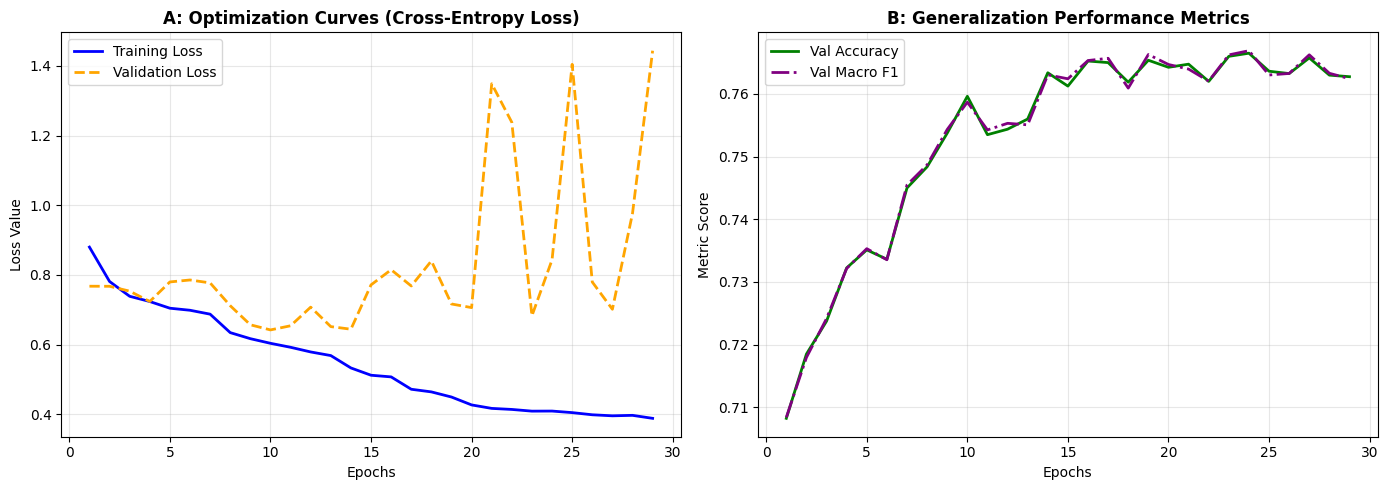


--- Final Consolidated Classification Report ---
              precision    recall  f1-score   support

   No Damage       0.82      0.81      0.82      2047
Minor Damage       0.70      0.76      0.73      1991
Major Damage       0.70      0.69      0.70      1984
   Destroyed       0.85      0.81      0.83      1978

    accuracy                           0.77      8000
   macro avg       0.77      0.77      0.77      8000
weighted avg       0.77      0.77      0.77      8000



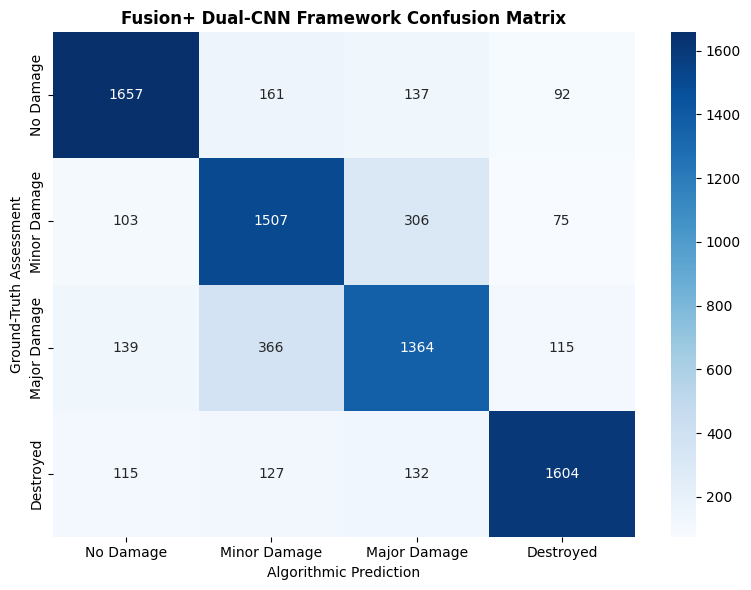


 Compiling Visual Testing Case Studies...


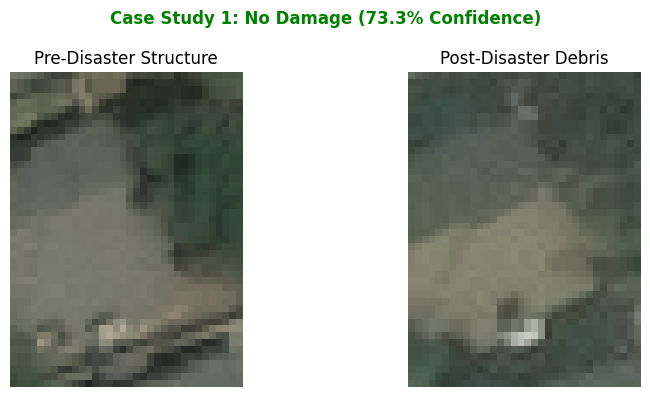

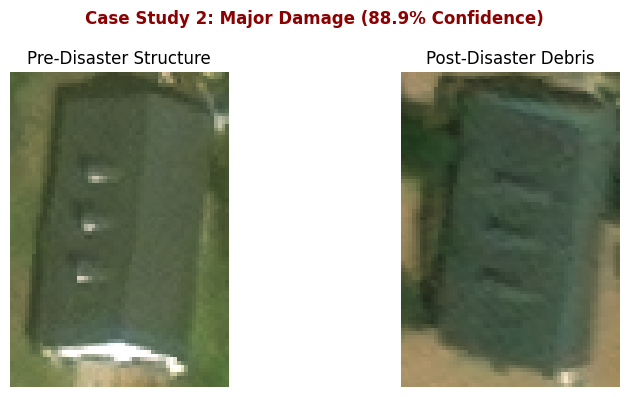

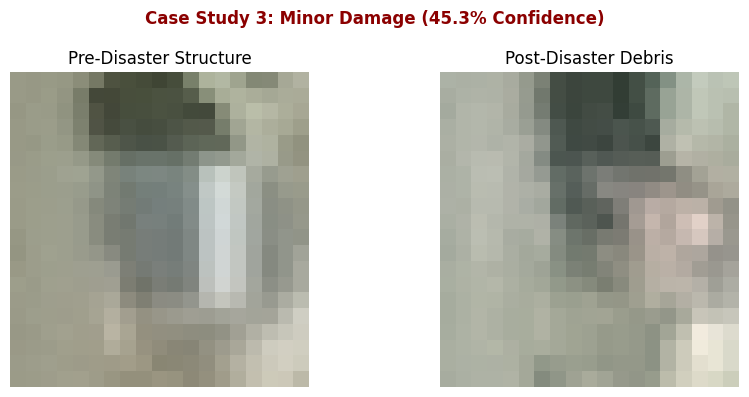


 ALL ASSETS COMPILED SUCCESSFULLY!
Images saved in your workspace: 'learning_curves.png', 'confusion_matrix.png', 'case_study_1.png', 'case_study_2.png', 'case_study_3.png'


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, models
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import copy
import os
import json
import cv2
import glob
from shapely import wkt
from PIL import Image

# ==========================================
# 1. INITIALIZE MODEL & ENVIRONMENT
# ==========================================
class FusionPlusModel(nn.Module):
    def __init__(self, num_classes=4):
        super(FusionPlusModel, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stream_a = nn.Sequential(*list(resnet.children())[:-1]) 
        effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.stream_b = effnet.features
        self.pool_b = nn.AdaptiveAvgPool2d(1) 
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 1280, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, pre_img, post_img):
        feat_a = self.stream_a(pre_img).view(pre_img.size(0), -1) 
        feat_b = self.pool_b(self.stream_b(post_img)).view(post_img.size(0), -1) 
        return self.classifier(torch.cat((feat_a, feat_b), dim=1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FusionPlusModel(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS = 50 
EARLY_STOPPING_PATIENCE = 5

# History containers for generating Learning Curves
history = {
    'train_loss': [], 'val_loss': [],
    'val_acc': [], 'val_f1': []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = 0.0
epochs_no_improve = 0

# ==========================================
# 2. PHASE 5: MASTER TRAINING LOOP
# ==========================================
print(f"🚀 Starting Unified Training Pipeline (Max Epochs: {EPOCHS})...")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    for pre_imgs, post_imgs, labels in train_loader:
        pre_imgs, post_imgs, labels = pre_imgs.to(device), post_imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pre_imgs, post_imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for pre_imgs, post_imgs, labels in val_loader:
            pre_imgs, post_imgs, labels = pre_imgs.to(device), post_imgs.to(device), labels.to(device)
            outputs = model(pre_imgs, post_imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='macro') 
    
    scheduler.step(avg_val_loss)
    
    # Append metrics to history logs
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    epoch_mins = (time.time() - start_time) / 60
    print(f"Epoch {epoch+1:02d} | Time: {epoch_mins:.2f}m | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}")
    
    # Checkpointing
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), '/kaggle/working/fusion_best_model.pth')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break

model.load_state_dict(best_model_wts)
print(" Training Phase Complete. Moving directly to evaluation analytics...")

# ==========================================
# 3. PHASE 6: AUTOMATED PLOTTING & EVALUATION
# ==========================================
print("\n Generating Research Analytics Figures...")

# Figure 1: Learning Curves (Loss & Accuracy Tracking)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Training Loss', color='blue', lw=2)
ax1.plot(epochs_range, history['val_loss'], label='Validation Loss', color='orange', linestyle='--', lw=2)
ax1.set_title('A: Optimization Curves (Cross-Entropy Loss)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['val_acc'], label='Val Accuracy', color='green', lw=2)
ax2.plot(epochs_range, history['val_f1'], label='Val Macro F1', color='purple', linestyle='-.', lw=2)
ax2.set_title('B: Generalization Performance Metrics', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Metric Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/learning_curves.png', dpi=300)
plt.show()

# Figure 2: Standard Evaluation Metrics Matrices
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for pre_imgs, post_imgs, labels in val_loader:
        pre_imgs, post_imgs, labels = pre_imgs.to(device), post_imgs.to(device), labels.to(device)
        outputs = model(pre_imgs, post_imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['No Damage', 'Minor Damage', 'Major Damage', 'Destroyed']
print("\n--- Final Consolidated Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Fusion+ Dual-CNN Framework Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Ground-Truth Assessment')
plt.xlabel('Algorithmic Prediction')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# 4. PHASE 7: MULTI-SAMPLE VISUAL CASE STUDIES
# ==========================================
print("\n Compiling Visual Testing Case Studies...")
TRAIN_DIR = '/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train'
json_candidates = glob.glob(os.path.join(TRAIN_DIR, 'labels', '*_pre_disaster.json'))[:3] # Grab 3 distinct files

transform_inf = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for i, json_path in enumerate(json_candidates):
    base_filename = os.path.basename(json_path)
    pre_img_path = os.path.join(TRAIN_DIR, 'images', base_filename.replace('.json', '.png'))
    post_img_path = os.path.join(TRAIN_DIR, 'images', base_filename.replace('_pre_disaster.json', '_post_disaster.png'))
    
    if not (os.path.exists(pre_img_path) and os.path.exists(post_img_path)):
        continue
        
    with open(json_path, 'r') as f:
        pre_data = json.load(f)
    
    buildings = pre_data['features']['xy']
    pre_img_full = cv2.cvtColor(cv2.imread(pre_img_path), cv2.COLOR_BGR2RGB)
    post_img_full = cv2.cvtColor(cv2.imread(post_img_path), cv2.COLOR_BGR2RGB)
    
    for building in buildings:
        if building['properties'].get('feature_type') != 'building':
            continue
        poly = wkt.loads(building['wkt'])
        minx, miny, maxx, maxy = poly.bounds
        pad = 5
        miny, maxy = max(0, int(miny)-pad), min(pre_img_full.shape[0], int(maxy)+pad)
        minx, maxx = max(0, int(minx)-pad), min(pre_img_full.shape[1], int(maxx)+pad)
        
        pre_crop = pre_img_full[miny:maxy, minx:maxx]
        post_crop = post_img_full[miny:maxy, minx:maxx]
        
        if pre_crop.size > 0 and post_crop.size > 0:
            pre_tensor = transform_inf(Image.fromarray(pre_crop)).unsqueeze(0).to(device)
            post_tensor = transform_inf(Image.fromarray(post_crop)).unsqueeze(0).to(device)
            
            with torch.no_grad():
                output = model(pre_tensor, post_tensor)
                probs = F.softmax(output, dim=1)
                conf, pred_idx = torch.max(probs, 1)
            
            fig, axes = plt.subplots(1, 2, figsize=(9, 4))
            title_color = 'green' if pred_idx.item() == 0 else 'darkred'
            fig.suptitle(f"Case Study {i+1}: {class_names[pred_idx.item()]} ({conf.item()*100:.1f}% Confidence)", 
                         fontsize=12, fontweight='bold', color=title_color)
            axes[0].imshow(pre_crop)
            axes[0].set_title("Pre-Disaster Structure")
            axes[0].axis('off')
            axes[1].imshow(post_crop)
            axes[1].set_title("Post-Disaster Debris")
            axes[1].axis('off')
            plt.tight_layout()
            plt.savefig(f'/kaggle/working/case_study_{i+1}.png', dpi=300)
            plt.show()
            break # Move to the next image file

print("\n ALL ASSETS COMPILED SUCCESSFULLY!")
print("Images saved in your workspace: 'learning_curves.png', 'confusion_matrix.png', 'case_study_1.png', 'case_study_2.png', 'case_study_3.png'")

In [19]:
# Compress the entire working directory into a single zip file, excluding any zip files
!zip -q -r /kaggle/working/all_final_assets.zip /kaggle/working/ -x "*.zip*"
print("⚡ Done! 'all_final_assets.zip' has been successfully created.")

⚡ Done! 'all_final_assets.zip' has been successfully created.
